<a href="https://colab.research.google.com/github/YYChang34/Text-Classification-with-RNN-LSTM-and-GRU/blob/main/Text_Classification_with_RNN_LSTM_and_GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text Classification with RNN, LSTM, and GRU

# Data Preprocessing

- Step 1:使用 imdb.load_data(num_words=10000) 載入 IMDB 電影評論數據集，並限制只使用最常見的 10,000 個單詞。這樣可以減少計算量，聚焦於最具代表性的詞彙，避免過多冗餘的低頻詞影響模型訓練。
- Step 2:由於 IMDB 數據集中的評論長度不一致，使用 pad_sequences 函數將所有文本填充到相同的長度。這裡設置 maxlen_train = 500，即每條評論的最大長度為 500 個單詞，長度不足的文本將進行填充，過長的文本將被截斷。
- Step 3:將train dataset分割成 80% train dataset & 20% validation dataset。
- Step 4:使用 Embedding 層來將每個單詞索引轉換為 128 維的詞向量，並且每條評論的最大長度是 500。




In [ ]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding
from sklearn.model_selection import train_test_split

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

maxlen_train = 500

x_train_padded = pad_sequences(x_train, maxlen=maxlen_train)

x_test_padded = pad_sequences(x_test, maxlen=maxlen_train)

x_train_padded, x_val, y_train, y_val = train_test_split(x_train_padded, y_train, test_size=0.2, random_state=42)

embedding_layer = Embedding(input_dim=10000, output_dim=128, input_length=maxlen_train)

print(f"Training data shape after padding and spliting: {x_train_padded.shape}")
print(f"Test data shape after padding: {x_test_padded.shape}")


Training data shape after padding and spliting: (20000, 500)
Test data shape after padding: (25000, 500)


# Model Implementation (RNN, LSTM and GRU)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout


rnn_model = Sequential([
    embedding_layer,
    SimpleRNN(units=50, return_sequences=True),
    Dropout(0.2),
    SimpleRNN(units=50, return_sequences=True),
    Dropout(0.2),
    SimpleRNN(units=50, return_sequences=True),
    Dropout(0.2),
    SimpleRNN(units=50),
    Dropout(0.2),
    Dense(units=1, activation='sigmoid')
])

rnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

### RNN Model Architecture

#### Input Layer:
- **SimpleRNN Layer**: 50 units with `return_sequences=True`, input shape `(window_size, 1)`
- **Dropout Layer**: Dropout rate of 0.2

#### Hidden Layer 1:
- **SimpleRNN Layer**: 50 units with `return_sequences=True`
- **Dropout Layer**: Dropout rate of 0.2

#### Hidden Layer 2:
- **SimpleRNN Layer**: 50 units with `return_sequences=True`
- **Dropout Layer**: Dropout rate of 0.2

#### Hidden Layer 3:
- **SimpleRNN Layer**: 50 units with `return_sequences=False`
- **Dropout Layer**: Dropout rate of 0.2

#### Output Layer:
- **Dense Layer**: 1 neuron with `Sigmoid` activation function

### Key Components

- **SimpleRNN Layer**：專門為處理序列數據（如時間序列、文本等）而設計的，並且具有記憶上一個時間步的能力。

- **Dropout Layer**：在每個 LSTM 層後應用 Dropout，這有助於防止模型過擬合。

- **Sigmoid Activation**：在 Output Layer 使用 `Sigmoid` activation，可以將每個輸出值映射到[0, 1]範圍，使模型能夠輸出每個樣本屬於某一類別的機率。

- **Dense Layer**：最終的 Dense Layer，只有一個神經元，輸出模型的預測結果。

- **Adam Optimizer**：Adam 是訓練模型時使用的優化器，可以加速收斂過程，並提升訓練的穩定性和效率。

- **Binary Crossentropy Loss Function**：`binary_crossentropy` 是二分類問題中的常用損失函數，尤其是在模型輸出為概率，像是這次使用 Sigmoid 時，它可以用來衡量模型預測的概率分佈與實際標籤之間的差異。

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

lstm_model = Sequential([
    embedding_layer,
    LSTM(units=50, return_sequences=True),
    Dropout(0.2),
    LSTM(units=50, return_sequences=True),
    Dropout(0.2),
    LSTM(units=50, return_sequences=True),
    Dropout(0.2),
    LSTM(units=50),
    Dropout(0.2),
    Dense(units=1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

### LSTM Model Architecture

#### Input Layer:
- **LSTM Layer**: 50 units with `return_sequences=True`, input shape `(window_size, 1)`
- **Dropout Layer**: Dropout rate of 0.2

#### Hidden Layer 1:
- **LSTM Layer**: 50 units with `return_sequences=True`
- **Dropout Layer**: Dropout rate of 0.2

#### Hidden Layer 2:
- **LSTM Layer**: 50 units with `return_sequences=True`
- **Dropout Layer**: Dropout rate of 0.2

#### Hidden Layer 3:
- **LSTM Layer**: 50 units with `return_sequences=False`
- **Dropout Layer**: Dropout rate of 0.2

#### Output Layer:
- **Dense Layer**: 1 neuron with `Sigmoid` activation function

### Key Components

- **LSTM Layer**：LSTM 能夠學習long-term data，特別適用於時間序列預測等任務。

- **Dropout Layer**：在每個 LSTM 層後應用 Dropout，這有助於防止模型過擬合。

- **Sigmoid Activation**：在 Output Layer 使用 `Sigmoid` activation，可以將每個輸出值映射到[0, 1]範圍，使模型能夠輸出每個樣本屬於某一類別的機率。

- **Dense Layer**：最終的 Dense Layer，只有一個神經元，輸出模型的預測結果。

- **Adam Optimizer**：Adam 是訓練模型時使用的優化器，可以加速收斂過程，並提升訓練的穩定性和效率。

- **Binary Crossentropy Loss Function**：`binary_crossentropy` 是二分類問題中的常用損失函數，尤其是在模型輸出為概率，像是這次使用 Sigmoid 時，它可以用來衡量模型預測的概率分佈與實際標籤之間的差異。

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout

gru_model = Sequential([
    embedding_layer,
    GRU(units=50, return_sequences=True),
    Dropout(0.2),
    GRU(units=50, return_sequences=True),
    Dropout(0.2),
    GRU(units=50, return_sequences=True),
    Dropout(0.2),
    GRU(units=50),
    Dropout(0.2),
    Dense(units=1, activation='sigmoid')
])

gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

### GRU Model Architecture

#### Input Layer:
- **GRU Layer**: 50 units with `return_sequences=True`, input shape `(window_size, 1)`
- **Dropout Layer**: Dropout rate of 0.2

#### Hidden Layer 1:
- **GRU Layer**: 50 units with `return_sequences=True`
- **Dropout Layer**: Dropout rate of 0.2

#### Hidden Layer 2:
- **GRU Layer**: 50 units with `return_sequences=True`
- **Dropout Layer**: Dropout rate of 0.2

#### Hidden Layer 3:
- **GRU Layer**: 50 units with `return_sequences=False`
- **Dropout Layer**: Dropout rate of 0.2

#### Output Layer:
- **Dense Layer**: 1 neuron with `Sigmoid` activation function

### Key Components

- **GRU Layer**：解決 RNN 和 LSTM 的一些問題，如梯度消失問題，並且 GRU 相比於 LSTM 更簡單且計算上更加高效，但同時保留了能夠學習長期依賴的能力。

- **Dropout Layer**：在每個 LSTM 層後應用 Dropout，這有助於防止模型過擬合。

- **Sigmoid Activation**：在 Output Layer 使用 `Sigmoid` activation，可以將每個輸出值映射到[0, 1]範圍，使模型能夠輸出每個樣本屬於某一類別的機率。

- **Dense Layer**：最終的 Dense Layer，只有一個神經元，輸出模型的預測結果。

- **Adam Optimizer**：Adam 是訓練模型時使用的優化器，可以加速收斂過程，並提升訓練的穩定性和效率。

- **Binary Crossentropy Loss Function**：`binary_crossentropy` 是二分類問題中的常用損失函數，尤其是在模型輸出為概率，像是這次使用 Sigmoid 時，它可以用來衡量模型預測的概率分佈與實際標籤之間的差異。

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
rnn_history = rnn_model.fit(x_train_padded, y_train, epochs=5, batch_size=64, validation_data=(x_val, y_val), callbacks=[early_stopping])
lstm_history = lstm_model.fit(x_train_padded, y_train, epochs=5, batch_size=64, validation_data=(x_val, y_val), callbacks=[early_stopping])
gru_history = gru_model.fit(x_train_padded, y_train, epochs=5, batch_size=64, validation_data=(x_val, y_val), callbacks=[early_stopping])

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 237s 745ms/step - accuracy: 0.8168 - loss: 0.4222 - val_accuracy: 0.7372 - val_loss: 0.5750
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 230s 736ms/step - accuracy: 0.8416 - loss: 0.3793 - val_accuracy: 0.7486 - val_loss: 0.5690
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 264s 742ms/step - accuracy: 0.8513 - loss: 0.3577 - val_accuracy: 0.7476 - val_loss: 0.5674
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 233s 745ms/step - accuracy: 0.8611 - loss: 0.3400 - val_accuracy: 0.7482 - val_loss: 0.5717
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 257s 730ms/step - accuracy: 0.8711 - loss: 0.3247 - val_accuracy: 0.7450 - val_loss: 0.5868
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 500s 2s/step - accuracy: 0.8274 - loss: 0.4061 - val_accuracy: 0.8090 - val_loss: 0.4360
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 499s 2s/step - accuracy: 0.8892 - loss: 0.2757 - val_accuracy: 0.8472 - val_loss: 0.3871
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 487s 2s/step - accuracy: 0.9391 - loss: 0.1713 - v

# Evaluation and Comparison


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

def evaluate_model(model, x_test, y_test):
    loss, accuracy = model.evaluate(x_test, y_test)

    # 預測結果
    y_pred = (model.predict(x_test) > 0.5).astype("int32")

    # 計算 Precision, Recall, F1-score
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Loss: {loss:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

# 評估RNN模型
print("\nEvaluating RNN Model:")
evaluate_model(rnn_model, x_test_padded, y_test)

# 評估LSTM模型
print("\nEvaluating LSTM Model:")
evaluate_model(lstm_model, x_test_padded, y_test)

# 評估GRU模型
print("\nEvaluating GRU Model:")
evaluate_model(gru_model, x_test_padded, y_test)


Evaluating RNN Model:
782/782 ━━━━━━━━━━━━━━━━━━━━ 99s 127ms/step - accuracy: 0.7373 - loss: 0.6092
782/782 ━━━━━━━━━━━━━━━━━━━━ 89s 114ms/step
Accuracy: 0.7402
Loss: 0.6042
Precision: 0.6860
Recall: 0.8857
F1-Score: 0.7732

Evaluating LSTM Model:
782/782 ━━━━━━━━━━━━━━━━━━━━ 178s 227ms/step - accuracy: 0.8626 - loss: 0.3773
782/782 ━━━━━━━━━━━━━━━━━━━━ 175s 224ms/step
Accuracy: 0.8641
Loss: 0.3741
Precision: 0.8692
Recall: 0.8572
F1-Score: 0.8632

Evaluating GRU Model:
782/782 ━━━━━━━━━━━━━━━━━━━━ 178s 227ms/step - accuracy: 0.8543 - loss: 0.4227
782/782 ━━━━━━━━━━━━━━━━━━━━ 174s 223ms/step
Accuracy: 0.8532
Loss: 0.4165
Precision: 0.8353
Recall: 0.8798
F1-Score: 0.8570


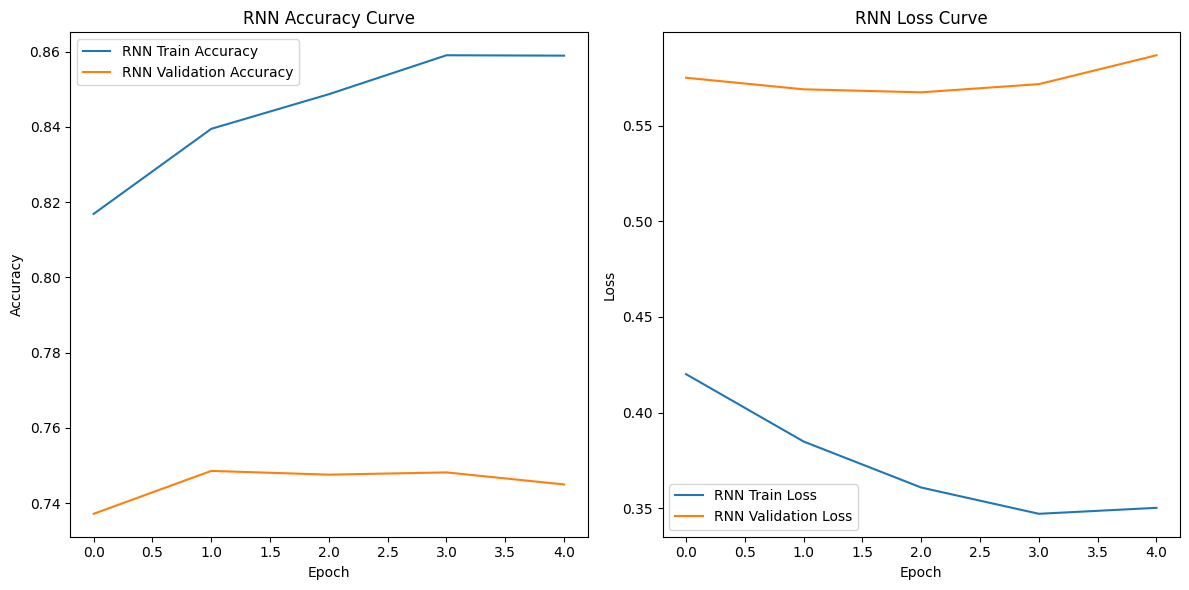

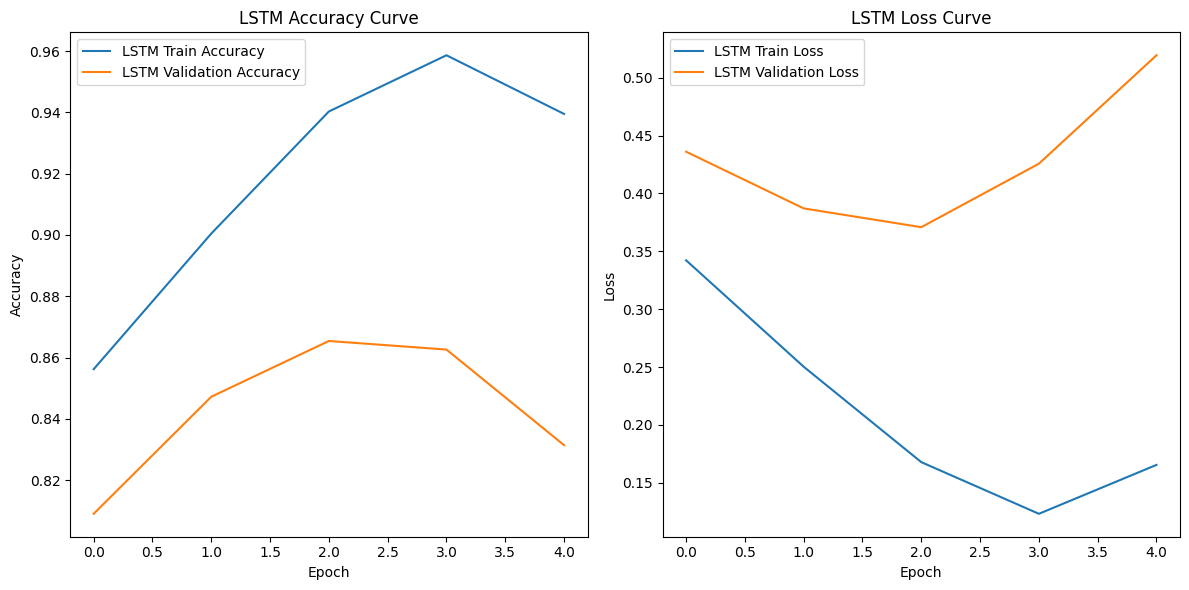

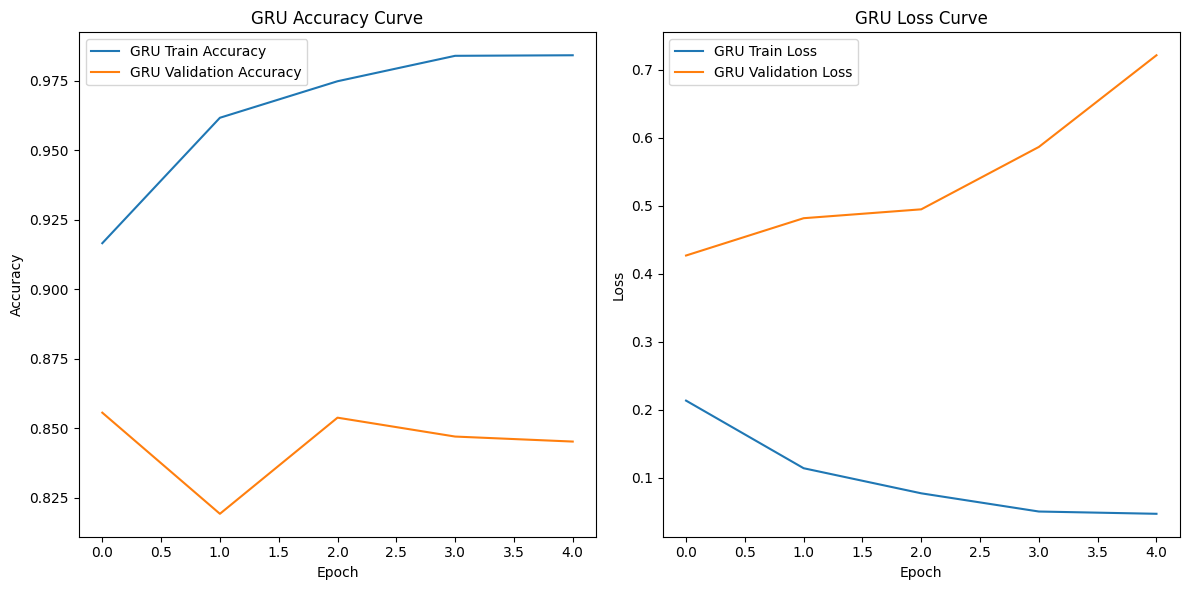

In [ ]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label=f'{model_name} Train Accuracy')
    plt.plot(history.history['val_accuracy'], label=f'{model_name} Validation Accuracy')
    plt.title(f'{model_name} Accuracy Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label=f'{model_name} Train Loss')
    plt.plot(history.history['val_loss'], label=f'{model_name} Validation Loss')
    plt.title(f'{model_name} Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()


    plt.tight_layout()
    plt.show()

plot_history(rnn_history, "RNN")
plot_history(lstm_history, "LSTM")
plot_history(gru_history, "GRU")


### 評估與比較分析

根據訓練結果，對 **RNN**、**LSTM** 和 **GRU** 模型進行了多項指標的評估，包括 **Accuracy**、**Loss**、**Precision**、**Recall** 和 **F1-score**。以下是這些模型在測試集上的性能：

#### RNN 模型結果:
- Accuracy: 0.7402
- Loss: 0.6042
- Precision: 0.6860
- Recall: 0.8857
- F1-Score: 0.7732

#### **LSTM 模型結果**:
- Accuracy: 0.8641
- Loss: 0.3741
- Precision: 0.8692
- Recall: 0.8572
- F1-Score: 0.8632

#### **GRU 模型結果**:
- Accuracy: 0.8532
- Loss: 0.4165
- Precision: 0.8353
- Recall: 0.8798
- F1-Score: 0.8570

### 評估指標解釋：
1. **Accuracy**：
   - Accuracy 衡量的是模型正確預測的比例。
   - 在這三個模型中，LSTM 模型表現最佳（0.8641），顯示出它在正確預測文本分類方面優於其他兩個模型。
   
2. **F1-score**：
   - F1-score 是 用來衡量分類模型的整體性能。
   - LSTM 在 F1-score 上表現最佳（0.8632），代表它在保持高Precision值的同時，也能有效地捕捉更多的正樣本。
   
3. **Precision**：
   - Precision 衡量的是模型預測為正類的樣本中，實際為正類的比例。
   - LSTM 的 Precision（0.8692）最高，顯示它在預測正類時最為準確。

4. **Recall**：
   - Recall衡量的是實際為正類的樣本中，模型成功預測為正類的比例。
   - RNN 的 Recall 最高（0.8857），表明它能夠捕捉到更多的正類樣本。

### 比較分析：
1. **RNN**：
   - 優點：RNN 模型在 **Recall** 上表現出色，這意味著它能夠成功檢測到更多的正類樣本，對於某些需要大量檢出正類的任務非常有用。
   - 缺點：儘管 RNN 在 Recall 上表現好，但它的 **Precision** 和 **Accuracy** 相對較低，顯示其預測正類時存在較多的錯誤，這會導致過多的假陽性（FP）。

2. **LSTM**：
   - 優點：LSTM 在所有指標上表現最佳，特別是在 **Accuracy**、**Precision** 和 **F1-score** 上。它具有強大的學習能力，能夠有效地處理長序列數據問題，並在較為複雜的任務中表現優異。
   - 缺點：相比於 RNN 和 GRU，LSTM 的計算量較大，訓練速度較慢，尤其是處理長序列數據時可能需要更多的時間和資源。

3. **GRU**：
   - 優點：GRU 也具有優秀的性能，並且在 **Recall** 和 **F1-score** 上表現接近 LSTM，這表明 GRU 在捕捉正類樣本和整體性能方面也表現不錯。GRU 的結構較簡單，計算成本較 LSTM 低。
   - 缺點：儘管 GRU 性能優良，但在 **Precision** 上略遜於 LSTM，顯示它在預測正類時稍微不如 LSTM 精確。

### 哪個模型表現最佳？
- **LSTM 模型** 表現最佳，尤其是在 **Accuracy**、**Precision** 和 **F1-score** 等指標上均優於 RNN 和 GRU，適合大多數需要精確預測的文本分類任務。
- **GRU 模型** 在計算效率和性能上是一個很好的替代方案，它的表現接近 LSTM，但計算量較低，適合對計算資源有較高要求的場景。
- **RNN 模型** 雖然在 **Recall** 上表現良好，但其 **Accuracy** 和 **Precision** 相對較低，對於要求高精度預測的任務而言，可能不如 LSTM 或 GRU 表現優異。

# Report

### 模型選擇、性能比較與整體總結

在本次任務中，總共使用了三種不同的模型：**RNN**、**LSTM** 和 **GRU**，以下是三種模型的分析：

#### **1. RNN**
- **優點**：
  - 相對較簡單，結構容易理解。
  - 在 **Recall** 上表現較好，能夠檢測到更多的正類樣本，對於某些要求高 Recall 值的任務非常有效，像是異常檢測。
- **缺點**：
  - 在 **Accuracy** 和 **Precision** 上表現較差，容易導致過多的假陽性（FP），即錯誤的將負類預測為正類。
  - **梯度消失問題**：在處理長序列數據時，RNN 可能無法有效學習長序列數據特徵的關係，這會導致模型性能的下降。

#### **2. LSTM**
- **優點**：
  - LSTM 對於需要處理長序列數據（如文本分類、時間序列預測等）的任務非常有效。
  - 在 **Accuracy**、**Precision** 和 **F1-score** 上表現最佳，綜合性較強，能夠學習到更複雜的模式。
- **缺點**：
  - 計算量較大，訓練速度較慢，尤其是在處理長序列數據時需要更多的計算資源。
  - 模型結構較為複雜，對硬體資源有較高的要求。

#### **3. GRU（門控循環單元）**
- **優點**：
  - GRU 是 LSTM 的簡單版本，結構簡單，比 LSTM 更加高效，計算量較低。
  - 在性能上接近 LSTM，但相比 LSTM 具有更少的參數和更快的訓練速度，對於資源有限的場景非常適用。
  - **F1-score** 和 **Recall** 都表現得很好，接近 LSTM，但計算速度更快。
- **缺點**：
  - 儘管 GRU 在性能上接近 LSTM，但在 **Precision** 上略有不如 LSTM，表現稍差。

### 性能比較：

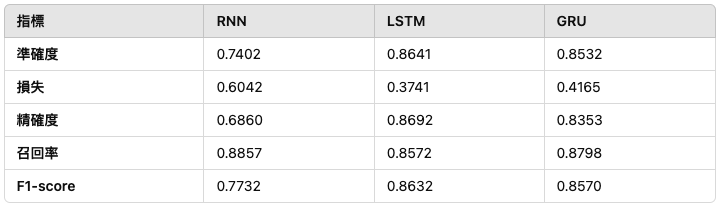

從表中可以看出，LSTM 在Accuracy、Precision、F1-score 和Loss等指標上均優於 RNN 和 GRU，顯示出 LSTM 在捕捉序列特徵、學習長序列數據方面的優勢。

### 模型推薦及選擇理由：

1. **推薦使用 LSTM 模型**：
   - 如果任務是 **複雜的文本分類** 或需要處理 **長序列數據**，LSTM 是最佳選擇。它在 **Accuracy** 和 **F1-score** 上表現優異，能夠有效地捕捉序列中的長期關係，對於需要從大量的上下文信息中提取特徵的任務非常適用。
   - 儘管 LSTM 的計算量較大，但在大多數文本分類問題中，其優越的性能能彌補這一缺點，尤其是在數據集較大或序列較長的情況下。

2. **如果需要更快的訓練速度或資源有限，選擇 GRU**：
   - **GRU** 是一個良好的替代方案，它在性能上接近 LSTM，但結構更簡單，計算量更低。如果你的數據集較小或者對訓練時間有較高要求，GRU 是一個理想選擇。
   - 它能夠提供接近 LSTM 的性能，並且更加高效，適合資源受限的情況。

3. **RNN 模型的使用情境**：
   - 雖然 RNN 在某些情況下，像是要求高 Recall 值的任務可能有一定優勢，但由於它在 **Accuracy** 和 **Precision** 上表現不佳，並且對長序列數據學習的能力有限，因此在處理較為複雜的文本分類任務時，LSTM 或 GRU 更為適合。

### 整體總結：
- **LSTM** 模型最為強大，適合需要處理長序列數據、學習複雜模式的文本分類任務。
- **GRU** 提供了與 LSTM 相似的性能，並且在計算效率和訓練時間上具有優勢，適合資源受限的場景。
- **RNN** 雖然在某些情況下能夠提供較好的Recall，但其 **Accuracy** 和 **Precision** 較低，對於需要高精度預測的應用來說並不理想。

因此，對於 **大多數文本分類任務**，推薦使用 **LSTM** 模型。